# SET-UP

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 1. Import Data

In [63]:
df = pd.read_csv('../Datasets/Raw/iris.csv')

In [64]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 2. Brief EDA

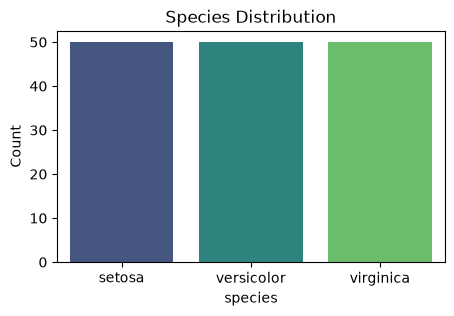

In [65]:
plt.figure(figsize=(5, 3))
sns.countplot(
    x=df['species'],
    palette='viridis'
)
plt.title('Species Distribution')
plt.ylabel('Count')
plt.show()

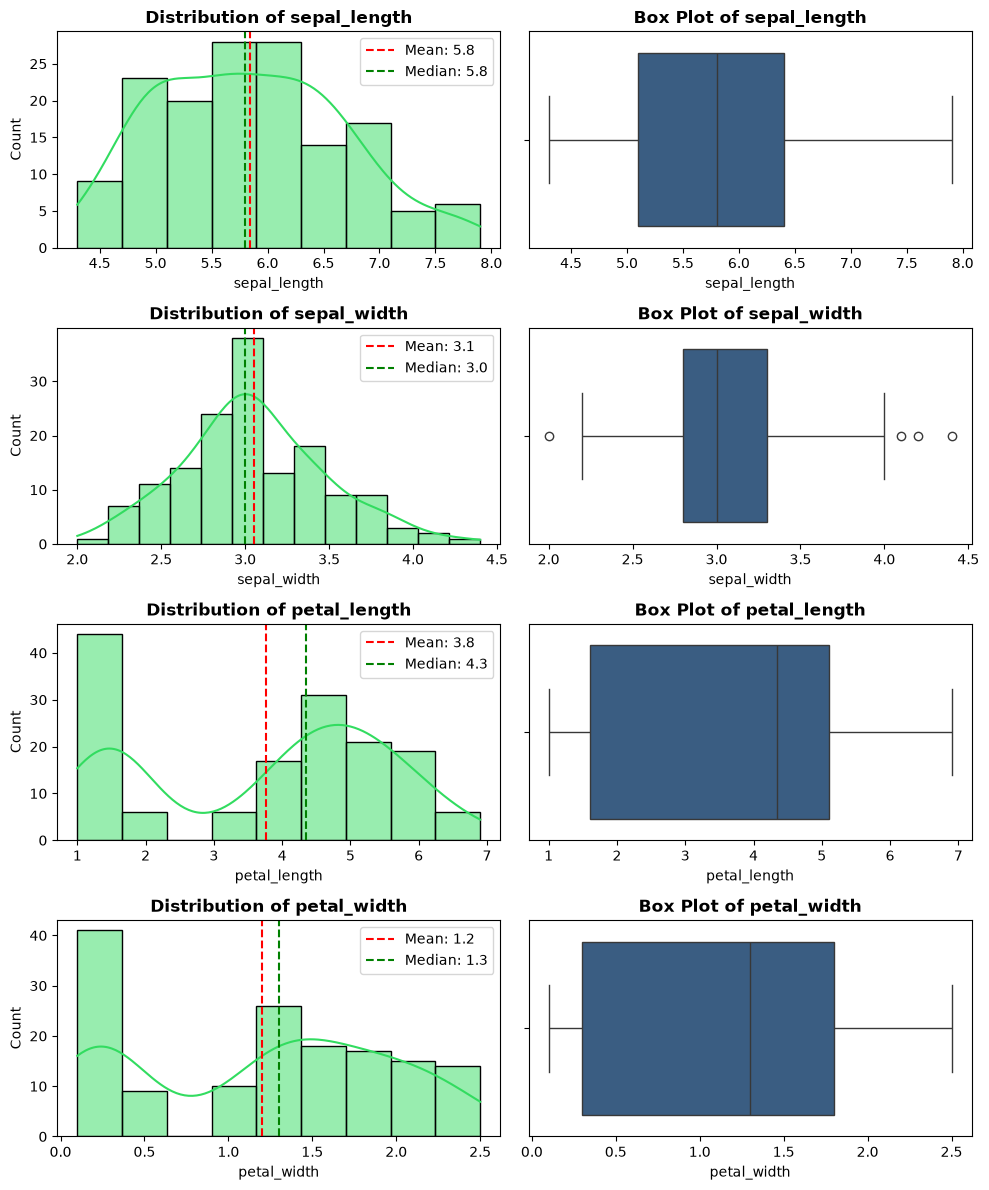

In [66]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        df,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = df[col].mean()
    median = df[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        df,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Missing & Duplicated

In [67]:
df.isna().sum().sum()

np.int64(0)

In [68]:
df.duplicated().sum()

np.int64(3)

In [69]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# 5. Data Splitting

In [70]:
X = df[num_cols]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Oversampling

In [71]:
y_train.value_counts()

species
versicolor    40
virginica     39
setosa        38
Name: count, dtype: int64

In [40]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [72]:
y_train.value_counts()

species
versicolor    40
virginica     39
setosa        38
Name: count, dtype: int64

# 7. Export Data

In [74]:
X_train.to_csv('../Datasets/Processed/X_train.csv', index=False)
X_test.to_csv('../Datasets/Processed/X_test.csv', index=False)
y_train.to_csv('../Datasets/Processed/y_train.csv', index=False)
y_test.to_csv('../Datasets/Processed/y_test.csv', index=False)